## How to simulate from the Dirichlet distribution?

Consider the Dirichlet distribution with parameters $a_1, \dots, a_k$. Let us assume that $a_1, \dots, a_k$ are all strictly positive. We will occasionally take some of the $a_j$-s to be small to mimic the effect of them being exactly zero. 

The Dirichlet distribution is a distribution on probability vectors $(p_1, \dots, p_k)$ (probability vector means that each $p_j \geq 0$ and $\sum_{j=1}^k p_j = 1$). In other words, if we simulate from the Dirichlet distribution, we obtain probability vectors. 

In [ ]:
a = np.array([1, 2, 1])
k = len(a)
dir_samples = np.random.dirichlet(a, size = 5) 
print(dir_samples)
#each row of dir_samples is a probability vector of length k that sums to 1. We can verify this by summing across the rows:
print(np.sum(dir_samples, axis=1))

[[2.26286803e-03 7.30060200e-01 2.67676932e-01]
 [1.36337244e-01 4.64166503e-01 3.99496253e-01]
 [3.11908477e-01 6.16701084e-01 7.13904382e-02]
 [2.79625669e-01 6.61841626e-01 5.85327053e-02]
 [7.22311440e-04 8.94584761e-01 1.04692928e-01]]
[1. 1. 1. 1. 1.]


When $k = 3$, we can visualize probability vectors as points in the triangle with vertices $(1, 0, 0)$ (corresponding to $p_1 = 1$), $(0, 1, 0)$ (corresponding to $p_2 = 1$) and $(0, 0, 1)$ (corresponding to $p_3 = 1$). This is done below. 

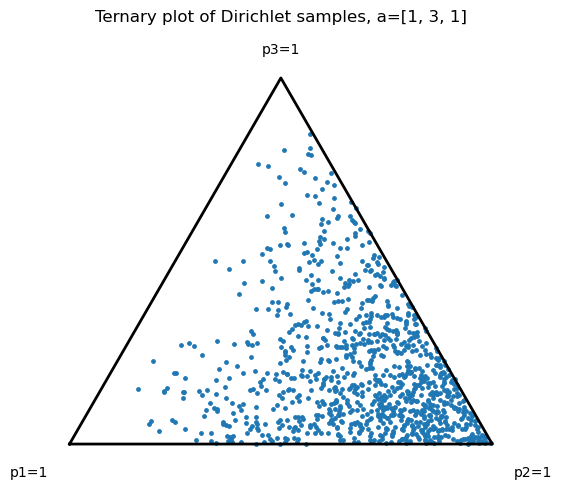

In [ ]:
N = 1000
# a = np.array([0.0002, 0.0002, 0.0002])
# a = np.array([1, 1, 1])
a = np.array([1,3,1])
# a = np.array([0.00002, 1, 1])
P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "p1=1", ha="right", va="top")
plt.text( 1.05, -0.05, "p2=1", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "p3=1", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")
plt.show()

From the above plot (with varying $a_1, a_2, a_3$), the following observations can be made: 
1. When $a_i = 1$ for all $i$, the generated probability vector samples are uniformly distributed over the triangle (when $k \geq 3$ the triangle is referred to as the probability simplex). 
2. When $a_1 = 1 = a_3$ and $a_2 = 5$ is large, then the probability vectors are piled up near the corner corresponding to $p_2 = 1$. 
3. When $a_i = \epsilon$ for a small $\epsilon$ (e.g., $\epsilon = 0.0002$), the points are basically superimposed on the corners of the triangle. 
4. When $a_1 = \epsilon$ and $a_2 = a_3 = 1$, then $p_1$ will always be very nearly zero. So the points will be on the line joining the $p_2 = 1$ and $p_3 = 1$ corners. The probability vectors here can be seen as being supported only on the two coordinates $2$ and $3$. 

Now let us how exactly to simulate from the Dirichlet $(a_1, \dots, a_k)$ distribution (in other words, what is the code underlying numpy's np.random.dirichlet). One can use Gamma distributed random variables to obtain Dirichlet samples. We discuss this below. Let us first recall basic facts about Gamma distributions. Suppose $X_i \overset{\text{ind}}{\sim} \text{Gamma}(\text{shape} = a_i, \text{rate} = 1)$ for $i = 1, \dots, n$. Recall that the Gamma distribution with shape $a$ and rate $\lambda$ has the density: 
\begin{align*}
    x \mapsto \frac{\lambda^a}{\Gamma(a)} x^{a-1} \exp(-\lambda x) I\{x > 0\} ~~ \text{ where } ~~ \Gamma(a) := \int_0^{\infty} x^{a-1} e^{-x} dx. 
\end{align*}
We will only be using Gamma distributions with rate parameter set to 1 (i.e., $\lambda = 1$). In this case, the Gamma density becomes: 
\begin{align*}
   x \mapsto \frac{1}{\Gamma(a)} x^{a-1} e^{-x} I\{x > 0\}. 
\end{align*}
The simplest $\text{Gamma}(a, \lambda)$ density correspnds to $a = 1$ and it is the standard exponential density $\text{Gamma}(1, \lambda) = \text{Exp}(\lambda)$ with density function $\lambda \exp(-\lambda x) I\{x > 0\}$. In particular, $\text{Gamma}(1, 1)$ is $\text{Exp}(1)$ with density $\exp(-x) I\{x > 0\}$. 

Now we can state the connection between Dirichlet $(a_1, \dots, a_k)$ and Gamma random variables: 
\begin{align*}
 \left(\frac{X_1}{X_1 + \dots + X_k},  \dots, \frac{X_k}{X_1 + \dots + X_k} \right) \sim \text{Dirichlet}(a_1, \dots, a_k)
\end{align*}
provided
\begin{align*}
    X_i \overset{\text{ind}}{\sim} \text{Gamma}(a_i, 1). 
\end{align*}
In other words, to generate a probability vector from the Dirichlet $(a_1, \dots, a_k)$ distribution, we simply generate independent Gamma $(a_i, 1)$ distributed random variables, and then normalize them (by dividing each of them with their sum) to get a probability vector. 

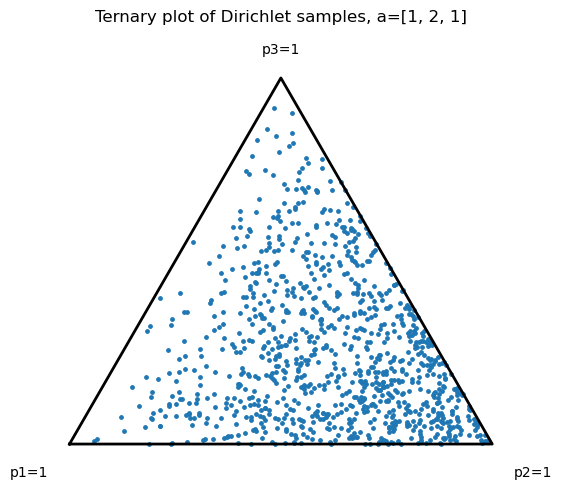

In [ ]:
N = 1000
# a = np.array([0.0002, 0.0002, 0.0002])
# a = np.array([1, 1, 1])
#a = np.array([1, 5, 1])
#a = np.array([0.00002, 1, 1])
a = np.array([1, 2, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "p1=1", ha="right", va="top")
plt.text( 1.05, -0.05, "p2=1", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "p3=1", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")
plt.show()

# Text Example

In [ ]:
tokens = """
the cat sat on the mat . the cat ate the fish . the dog sat on the mat .
the dog chased the cat . the cat ran from the dog . you see the cat .
you see the dog . you see the mat . i see the cat . i see the dog .
the cat sat on the fish . the dog ate the fish . you see the fish .
""".split()

In [ ]:
vocab = sorted(set(tokens))
w2i = {w: idx for idx, w in enumerate(vocab)}
i2w = {idx: w for w, idx in w2i.items()}
k = len(vocab)
n = len(tokens)
print(f"Tokens n = {n},  Vocabulary size k = {k}\n")
print("Vocabulary:", vocab)
print("tokens:", tokens)

## i.i.d Model

The observed counts for each of the $k$ words are given below. 

In [ ]:
counts = Counter(tokens)
print("Word counts:")
for w in vocab:
    print(f"  {w:>8s}: {counts[w]}")

We can use the Dirichlet-Multinomial inference here with prior Dirichlet $(0, \dots, 0)$. This leads to the posterior Dirichlet $(x_1, \dots, x_k)$ where $x_i$ is the observed count for the $i$-th word. We can use this fitted model to do sentence generation. We first draw $(p_1, \dots, p_k)$ from Dirichlet $(x_1, \dots, x_k)$ and then draw words from sequentially from Multinomial $(1; p_1, \dots, p_k)$ until we get a '.' (period). 

In [ ]:
np.random.seed(42)
# Dirichlet posterior parameters
alpha = np.array([counts[w] for w in vocab], dtype=float)
print("Generating sentences from the i.i.d model posterior posterior:\n")
M = 20 #this is the number of sentences
for s in range(M):
    # Step 1: Draw a probability vector from the Dirichlet posterior
    p = np.random.dirichlet(alpha)    
    # Step 2: Generate words until '.'
    sentence = []
    while True:
        word_idx = np.random.choice(k, p=p)
        word = i2w[word_idx]
        sentence.append(word)
        if word == '.':
            break
    print(f"  Sentence {s+1}: {' '.join(sentence)}")

These sentences are of course not realistic, which means that our model is too silly and unrealistic for this dataset. Note that this model works directly with the individual word counts but ignores any information about how words occur in specific sequences. A slighly improved model can be obtained by working with bigram counts as opposed to individual word counts. 

## AR(1) model (also known as the Markov or Bigram model)

This model uses bigram counts (and not the raw data directly). Below we compute the bigram counts $x_{j \mid i}$ as well as $x_i = \sum_{j=1}^k x_{j \mid i}$. 

In [ ]:
# --- 2. Bigram counts: X[j, i] = x_{j|i} = # times word j follows word i ---
X = np.zeros((k, k), dtype=np.int64)
for t in range(1, n):
    i_prev = w2i[tokens[t - 1]]  # i = previous word
    j_next = w2i[tokens[t]]      # j = next word
    X[j_next, i_prev] += 1

# x_i = sum_j x_{j|i}  (times i appears as the previous word)
x_prev = X.sum(axis=0)  # shape (k,)

print(X)
print(x_prev)

The first column refers to the number of times each word appears after '.'. More specifically, after '.', 'i' appears 2 times, 'the' appears 6 times and 'you' appears 4 times. And the sum of these numbers is the number of times '.' appears as the previous word. 

The next function calculates the log-Evidence for given values of $a_1, \dots, a_k$. Note that Evidence is the probability of obtaining the bigram sequence given values of $a_1, \dots, a_k$. 

In [ ]:
# --- 3. Log marginal likelihood (evidence) up to constants in a ---
# Here we parameterize a = (a_1,...,a_k) and A = sum_j a_j.
# The marginal over all rows i is:
#   prod_i [ Γ(A)/Γ(x_i + A) * prod_j Γ(x_{j|i}+a_j)/Γ(a_j) ]
# (multinomial coefficients omitted since they do not depend on a)

def log_evidence(a):
    A = a.sum()
    val = 0.0
    for i in range(k):
        if x_prev[i] == 0:
            continue
        val += gammaln(A) - gammaln(x_prev[i] + A)
        val += (gammaln(X[:, i] + a) - gammaln(a)).sum()
    return val

The next function calculates the gradient of the log-evidence using the digamma function (which is in-built in scipy, and is the derivative of the logarithm of the Gamma function). The notes has the exact formula for the gradient in terms of the digamma function. 

In [ ]:
def grad_log_evidence(a):
    A = a.sum()
    g = np.zeros(k)
    for i in range(k):
        if x_prev[i] == 0:
            continue
        # vector part: sum_i [ ψ(x_{j|i}+a_j) - ψ(a_j) ]
        g += digamma(X[:, i] + a) - digamma(a)
        # scalar part from A: sum_i [ ψ(A) - ψ(x_i + A) ] added to every component
        g += digamma(A) - digamma(x_prev[i] + A)
    return g


The code below maximizes the log-Evidence with respect to $a_1, \dots, a_k$. It uses a simple gradient ascent method. It calculates the gradient of the log-Evidence at the current value of $a = (a_1, \dots, a_k)$ and takes a step in that direction. A line search is done in that direction to find the best step-size. 

In [ ]:
a = 1 * np.ones(k) #initial values of a_1, \dots, a_k

print("Optimizing hyperparameters a = (a_1,...,a_k)...")
for it in range(3000):
    log_a = np.log(a)
    le = log_evidence(a)
    g = grad_log_evidence(a) * a  # chain rule: d/d(log a) = a * d/da
    step = 0.01
    for _ in range(10):
        trial = np.exp(log_a + step * g).clip(1e-10)
        if log_evidence(trial) > le:
            break
        step *= 0.5
    a = np.exp(log_a + step * g).clip(1e-10)
    if it % 100 == 0 or it == 299:
        print(f"  iter {it:3d}: log_ev = {le:.2f}, A = {a.sum():.3f}")

A = a.sum()


Below are the values of the estimated $a_1, \dots, a_k$ (and their sum $A = a_1 + \dots + a_k$). 

In [ ]:
print(f"\nOptimal A = {A:.3f}\n")
print(f"{'word':>8s}  {'a_j':>10s}")
print("-" * 30)
for j in range(k):
    print(f"{vocab[j]:>8s}  {a[j]:10.4f}")

Having obtained $a_1, \dots, a_k$, we compute below the posterior mean estimates of $p_{j \mid i}$. 

In [ ]:
P_hat = np.zeros((k, k))
for i in range(k):
    P_hat[:, i] = (X[:, i] + a) / (x_prev[i] + A)
print(P_hat)

In [ ]:
print(f"\n{'='*45}")
print("NEXT-WORD PREDICTIONS (posterior mean)")
print(f"{'='*45}")

#The following code predicts the top five most probable next words for a given word
def predict_next(prev_word, top_k=5):
    i = w2i[prev_word]
    probs = P_hat[:, i]                 # probs over j given i
    ranked = np.argsort(probs)[::-1]
    return [(i2w[j], probs[j]) for j in ranked[:top_k]]


for ctx in ['the', 'cat', 'you', 'dog', '.', 'on']:
    i = w2i[ctx]
    lam = A / (x_prev[i] + A)  # shrinkage weight on the prior mean m
    print(f"\nAfter '{ctx}'  (x_i={int(x_prev[i])}, λ={lam:.3f}):")
    for word, prob in predict_next(ctx, top_k=5):
        bar = '█' * int(prob * 40)
        print(f"  {word:>8s}  {prob:.3f}  {bar}")


The code below generates sentences using this model. It takes as input a starting word (e.g., '.') and then starts generating from there until the period '.' appears. Sentence generation can be done in two different ways here. The first way uses the Bayesian estimates of $p_{j \mid i}$ and generates words from multinomials. The second way also generates $p_{j \mid i}$ from their posterior first before generating from multinomials. 

In [ ]:
def generate(start_word, length=12, seed=45):
    rng = np.random.default_rng(seed)
    words = [start_word]
    for _ in range(length):
        i = w2i[words[-1]]
        j = rng.choice(k, p=P_hat[:, i])
        words.append(i2w[j])
        if words[-1] == '.':
            break
    return ' '.join(words)

print(f"\n{'='*45}")
print("GENERATED SENTENCES")
print(f"{'='*45}\n")
for s in range(20):
    print("  " + generate('.', seed=45 + s))

You can ignore the starting period while interpreting each of these sentences. 

In the above, we fixed the Bayesian estimate of $P[i, j]$ while generating the sentences. We can also draw $P$ from the correct Bayesian posterior, before generating each sentence. This is done below.



In [ ]:
def sample_P_posterior(rng):
    """
    Sample a full transition matrix P from the posterior.
    Each column i is p_{·|i} ~ Dirichlet(X[:, i] + a).
    """
    P = np.zeros((k, k))
    for i in range(k):
        alpha = X[:, i] + a
        P[:, i] = rng.dirichlet(alpha)
    return P

def generate_from_P(start_word, P, length=12, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    words = [start_word]
    for _ in range(length):
        i = w2i[words[-1]]
        j = rng.choice(k, p=P[:, i])
        words.append(i2w[j])
        if words[-1] == '.':
            break
    return ' '.join(words)

def generate_posterior_sampled(start_word, length=12, seed=45):
    """
    For THIS sentence: sample P ~ posterior, then generate using that P.
    """
    rng = np.random.default_rng(seed)
    P = sample_P_posterior(rng)
    return generate_from_P(start_word, P, length=length, rng=rng)

# --- 9. Generate sentences ---
print(f"\n{'='*45}")
print("GENERATED SENTENCES (posterior-sampled P per sentence)")
print(f"{'='*45}\n")
for s in range(20):
    print(" " + generate_posterior_sampled('.', seed=45 + s))

Overall these sentences are more realistic compared to the simple i.i.d (bag of words) model. Obviously, more sophisticated language models will  yield much more realistic sentences. 

### Comparison to classical bootstrap samples

In the classical bootstrap, one obtains re-samples by sampling with replacement from the observed data. 

In [ ]:
bootstrap_samples = np.random.choice(np.array([26.6, 38.5, 34.4]), size=(10, 3), replace=True)
print(bootstrap_samples)

[[34.4 38.5 34.4]
 [34.4 34.4 26.6]
 [38.5 34.4 26.6]
 [26.6 38.5 34.4]
 [38.5 34.4 38.5]
 [26.6 34.4 34.4]
 [26.6 26.6 38.5]
 [34.4 26.6 26.6]
 [34.4 26.6 38.5]
 [38.5 26.6 34.4]]


Note that the order of numbers in each bootstrap sample is irrelevant. Each bootstrap sample contains a subset of the three observed numbers $26.6, 38.5, 34.4$. We can obtain an equivalent representation of the bootstrap samples by simply tracking the proportion of times 26.6 appears in the sample, the proportion of times 38.5 appears and the proportion of times 34.4 appears. For example, in this tracking scheme, the bootstrap sample $34.4, 34.4, 26.6$ becomes $1/3, 0, 2/3$. Note that these proportions (because they are nonnegative and sum to one) can also be viewed as probability vectors, so they can be plotted on the probability triangle. This is done below. 

In [ ]:
N = 1000
bootstrap_samples = np.random.choice(np.array([26.6, 38.5, 34.4]), size=(N, 3), replace=True)
values = np.array([26.6, 38.5, 34.4])
proportion_samples = (bootstrap_samples[..., None] == values).mean(axis=1)
print(proportion_samples)

[[0.         0.33333333 0.66666667]
 [1.         0.         0.        ]
 [0.         0.66666667 0.33333333]
 ...
 [0.         0.33333333 0.66666667]
 [0.         0.         1.        ]
 [0.         0.66666667 0.33333333]]


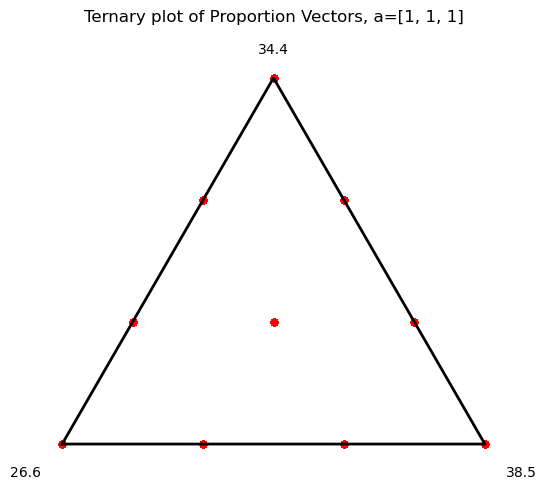

In [ ]:
P = proportion_samples
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=20, alpha=1, color = 'red')

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Proportion Vectors, a={a.tolist()}")
plt.show()

Here we see the discrete nature of the classical bootstrap samples. The proportion vectors take only 10 distinct values (even though we generated $N = 1000$ of these proportion vectors). Below we plot both the Bayesian bootstrap posterior probability vectors and the classical bootstrap proportion vectors in the same plot. 

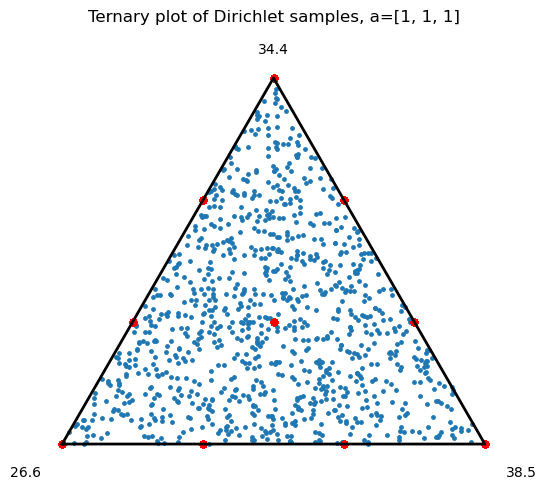

In [ ]:
N = 1000
a = np.array([1, 1, 1])
k = len(a)
gamma_samples = np.random.gamma(shape=a, scale=1, size=(N, k))
P = gamma_samples / np.sum(gamma_samples, axis=1, keepdims=True)

#P = np.random.dirichlet(a, size=N)  # shape (N,3)
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])

plt.figure(figsize=(6, 6))
plt.plot(tri[:,0], tri[:,1], linewidth=2, color = 'black')

plt.scatter(x, y, s=6, alpha=1)

# label vertices (where each probability is 1)
plt.text(-0.05, -0.05, "26.6", ha="right", va="top")
plt.text( 1.05, -0.05, "38.5", ha="left",  va="top")
plt.text(0.5, np.sqrt(3)/2 + 0.05, "34.4", ha="center", va="bottom")

plt.axis("equal")
plt.axis("off")
plt.title(f"Ternary plot of Dirichlet samples, a={a.tolist()}")

P = proportion_samples
p1, p2, p3 = P[:,0], P[:,1], P[:,2]

# --- barycentric -> Cartesian (equilateral triangle) ---
x = p2 + 0.5 * p3
y = (np.sqrt(3)/2) * p3

# --- draw triangle + scatter ---
tri = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2], [0, 0]])


plt.scatter(x, y, s=20, alpha=1, color = 'red')

plt.show()

For classical bootstrap, we can generate the proportion vectors directly without actually resampling original data. This is because each proportion vector is itself distributed according to the following distribution: 
\begin{align*}
   (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}


In [ ]:
prop_vectors = (np.random.multinomial(3, pvals=[1/3, 1/3, 1/3], size=N))/3
print(prop_vectors)

[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.         0.66666667]
 [0.33333333 0.33333333 0.33333333]
 ...
 [0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.         0.33333333 0.66666667]]


In practice, the goal in these kinds of problems is not to estimate the whole probability distribution of the experiment generating the observations, but instead, to estimate some parameter such as the mean or median $\theta$ of that probability distribution. In each of these methods (classical bootstrap or Bayesian bootstrap), posterior samples for $\theta$ are obtained by calculating the mean or mode for each bootstrap sample. 

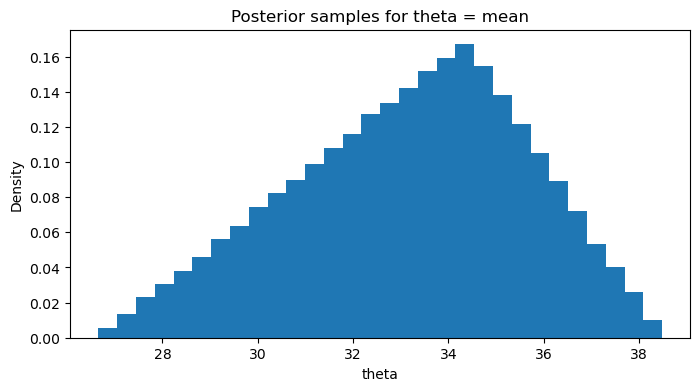

33.166666666666664 33.166489960603506


In [ ]:
#Posterior samples for theta = mean
x_obs = np.array([26.6, 38.5, 34.4])
n = len(x_obs)
M = 100000
W = np.random.dirichlet(alpha=np.ones(n), size=M)
theta_samples = W @ x_obs
plt.figure(figsize=(8, 4))
plt.hist(theta_samples, bins=30, density=True)
plt.title("Posterior samples for theta = mean")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()
print(np.mean(x_obs), np.mean(theta_samples))

It is interesting that the posterior of $\theta$ is not uniform over its range, even though the posterior of $(w_1, w_2, w_3)$ was uniform over all probability vectors of length 3. The posterior of $\theta$ is peaked near the mean of the observed data. 

Next we plot the sample of $\theta$ obtained from classical bootstrap. 

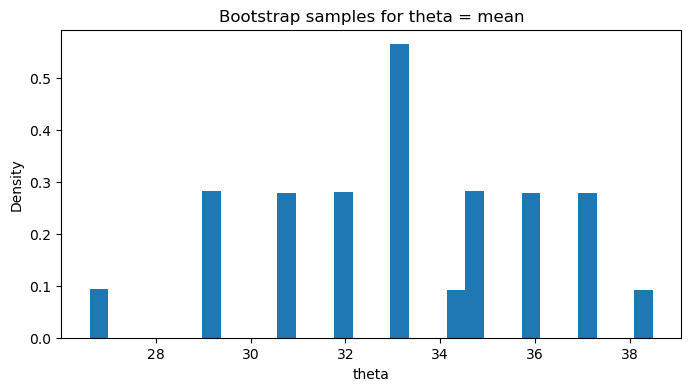

33.166666666666664 33.166489960603506


In [ ]:
#Posterior samples for theta = mean
x_obs = np.array([26.6, 38.5, 34.4])
n = len(x_obs)
M = 100000
V = np.random.multinomial(n = n, pvals = np.ones(n)/n, size=M)/n
theta_samples_b = V @ x_obs
plt.figure(figsize=(8, 4))
plt.hist(theta_samples_b, bins=30, density=True)
plt.title("Bootstrap samples for theta = mean")
plt.xlabel("theta")
plt.ylabel("Density")
plt.show()
print(np.mean(x_obs), np.mean(theta_samples))

The classical bootstrap histogram for $\theta$ appears very choppy. This is because of its discrete nature and the fact that we have only 3 observations here. It is also not uniform, and is peaked at the mean of the observed data. 

When $n$ is large, both Bayesian bootstrap and the classical bootstrap will give similar results. 

Back to our favourite problem: 

*Suppose a scientist makes 6 numerical measurements $26.6, 38.5, 34.4, 34, 31, 23.6$ on an unknown real-valued physical quantity $\theta$. On the basis of these measurements, what can be inferred about $\theta$?*

We now use the model: 
\begin{align*}
    X_1, \dots, X_n \mid P \overset{\text{i.i.d}}{\sim} P ~~ \text{ and } ~~ \theta = \text{mean corresponding to} ~ P
\end{align*}
We use discretization and assume that $P$ is supported on a large finite set $G = \{g_1, \dots, g_k\}$ e.g., $G = \{0.1, 0.2, \dots, 99.9, 100.0\}$. Let the probabilities assigned by $P$ to $g_1, \dots, g_k$ be $p_1, \dots, p_k$. We use the noninformative prior: 
\begin{align*}
   (p_1, \dots, p_k) \sim \text{Dirichlet}(0, \dots, 0). 
\end{align*}
This leads to the posterior: 
\begin{align*}
  P \mid X_1 = x_1, \dots, X_n = x_n \sim \sum_{i=1}^n w_i \delta_{\{x_i\}} ~\text{where} ~ (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
The posterior of $\theta$ is therefore: 
\begin{align*}
   \theta \mid \text{data} \sim \sum_{i=1}^n w_i x_i \text{ where } (w_1, \dots, w_n) \sim \text{Dirichlet}(1, \dots, 1). 
\end{align*}
Below we simulate from this posterior, and obtain posterior mean and 95\% credible interval.

In [ ]:
x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6])
#x_obs = np.array([26.6, 38.5, 34.4, 34, 31, 23.6, 100]) #this data will reveal differences between estimation of mean and median
n = len(x_obs)
M = 100000 #number of posterior samples
np.random.seed(42) #for reproducibility
W = np.random.dirichlet(alpha = np.ones(n), size=M) #M samples from the Dirichlet distribution
theta_samples = W @ x_obs #compute the posterior samples of theta

theta_mean = np.mean(theta_samples)
theta_ci = np.quantile(theta_samples, [0.025, 0.975])

print(f"Posterior mean (Bayesian Bootstrap) of theta: {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean (Bayesian Bootstrap) of theta: 31.35
95% credible (Bayesian Bootstrap) interval: [27.53, 34.90]


Below is a histogram of all the posterior samples. 

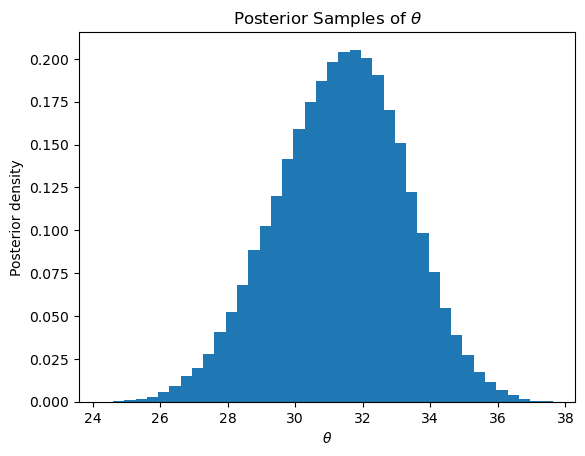

In [ ]:
plt.hist(theta_samples, bins=40, density=True)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior density")
plt.title("Posterior Samples of $\\theta$")
plt.show()

The usual bootstrap generates samples of the form: 
\begin{align*}
   \sum_{i=1}^n v_i \delta_{\{x_i\}} ~~ \text{ where } ~~ (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}
This leads to samples of $\theta$ (which is the mean of $P$) generated according to: 
\begin{align*}
   \sum_{i=1}^n v_i x_i ~~ \text{ where } ~~ (v_1, \dots, v_n) \sim \frac{1}{n}\text{Multinomial}(n; 1/n, \dots, 1/n). 
\end{align*}

In [ ]:
#Bootstrap samples
V = np.random.multinomial(n=n, pvals=np.ones(n)/n, size=M)/n
theta_bootstrap = V @ x_obs

Below we plot the histograms of the bootstrap and Bayesian bootstrap samples. 

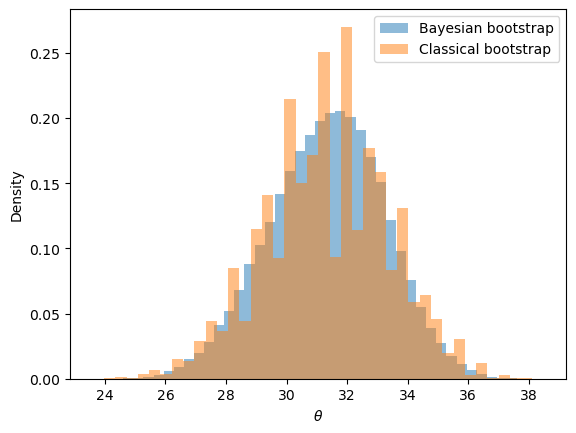

In [ ]:
plt.hist(theta_samples, bins=40, density=True, alpha=0.5, label="Bayesian bootstrap")
plt.hist(theta_bootstrap, bins=40, density=True, alpha=0.5, label="Classical bootstrap")
plt.legend()
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.show()

The two histograms overlap considerably, but the classical bootstrap histogram is much rougher compared to the Bayesian bootstrap histogram. 

Below we compute the bootstrap mean and confidence intervals, and compare them to the Bayesian bootstrap mean and confidence intervals.

In [ ]:
theta_mean_bootstrap = np.mean(theta_bootstrap)
theta_ci_bootstrap = np.quantile(theta_bootstrap, [0.025, 0.975])

print(f"Bootstrap mean of theta: {theta_mean_bootstrap:.2f}")
print(f"95% bootstrap confidence interval: [{theta_ci_bootstrap[0]:.2f}, {theta_ci_bootstrap[1]:.2f}]")

print(f"Posterior mean (Bayesian Bootstrap) of theta: {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval: [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Bootstrap mean of theta: 31.35
95% bootstrap confidence interval: [27.13, 35.15]
Posterior mean (Bayesian Bootstrap) of theta: 31.35
95% credible (Bayesian Bootstrap) interval: [27.53, 34.90]


Note that these intervals are very close to each other but the Bayesian bootstrap interval is slightly narrower. It can be checked that: 
\begin{align*}
   \mathbb{E} \left(\theta \mid \text{data} \right) = \mathbb{E} \left(\sum_{i=1}^n w_i x_i \mid \text{data} \right) = \bar{x} ~~ \text{ and } ~~ \text{var} \left(\theta \mid \text{data}  \right) = \text{var} \left(\sum_{i=1}^n w_i x_i \mid \text{data}  \right) = \frac{1}{n(n+1)} \sum_{i=1}^n (x_i - \bar{x})^2. 
\end{align*}
and
\begin{align*}
   \mathbb{E} \left(\sum_{i=1}^n v_i x_i \mid \text{data} \right) = \bar{x} ~~ \text{ and } ~~ \text{var} \left(\sum_{i=1}^n v_i x_i \mid \text{data} \right) = \frac{1}{n} \frac{1}{n} \sum_{i=1}^n (x_i - \bar{x})^2
\end{align*}
So the Bayesian bootstrap variance is very slightly (by a factor of $n/(n+1)$) smaller than the bootstrap variance. 


### Median Estimation

Instead of assuming that $\theta$ is the mean of $P$, we can assume that $\theta$ is the median of $P$. We would then be computing the medians of the generated samples (either the Bayesian bootstrap samples, or the usual bootstrap samples).

For an arbitrary probability measure $Q$, we define its median as: 
\begin{align*}
   \inf \left\{x: Q(-\infty, x] \geq 0.5 \right\} 
\end{align*}
This definition makes sense even when $Q$ is discrete. As an example, note that if $Q$ is the discrete distribution taking the two values 0 and 1 with equal probabilities, then the median of $Q$ according to the above definition is 0. 

Below we compute the medians corresponding to each Bayesian boostrap sample. 

In [ ]:
order_obs = np.argsort(x_obs)
x_sorted = x_obs[order_obs]
W_sorted = W[:, order_obs]
cdf = np.cumsum(W_sorted, axis=1)
median_idx = np.argmax(cdf >= 0.5, axis=1)
theta_median_samples = x_sorted[median_idx]

In [ ]:
theta_median_mean = np.mean(theta_median_samples)
theta_median_ci = np.quantile(theta_median_samples, [0.025, 0.975])

print(f"Posterior mean (Bayesian Bootstrap) of theta (median): {theta_median_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval for theta (median): [{theta_median_ci[0]:.2f}, {theta_median_ci[1]:.2f}]")

#Compare to mean: 
print(f"Posterior mean (Bayesian Bootstrap) of theta (mean): {theta_mean:.2f}")
print(f"95% credible (Bayesian Bootstrap) interval for theta (mean): [{theta_ci[0]:.2f}, {theta_ci[1]:.2f}]")

Posterior mean (Bayesian Bootstrap) of theta (median): 31.78
95% credible (Bayesian Bootstrap) interval for theta (median): [23.60, 38.50]
Posterior mean (Bayesian Bootstrap) of theta (mean): 31.35
95% credible (Bayesian Bootstrap) interval for theta (mean): [27.53, 34.90]


Next we do the same thing for the usual bootstrap. 

In [ ]:
order_obs = np.argsort(x_obs)
x_sorted = x_obs[order_obs]
V_sorted = V[:, order_obs]
cdf = np.cumsum(V_sorted, axis=1)
median_idx = np.argmax(cdf >= 0.5, axis=1)
theta_median_bootstrap = x_sorted[median_idx]

In [ ]:
theta_median_bootstrap_mean = np.mean(theta_median_bootstrap)
theta_median_bootstrap_ci = np.quantile(theta_median_bootstrap, [0.025, 0.975])

print(f"Posterior mean (Bootstrap) of theta (median): {theta_median_bootstrap_mean:.2f}")
print(f"95% credible (Bootstrap) interval for theta (median): [{theta_median_bootstrap_ci[0]:.2f}, {theta_median_bootstrap_ci[1]:.2f}]")

#Compare to mean: 
print(f"Posterior mean (Bootstrap) of theta (mean): {theta_mean_bootstrap:.2f}")
print(f"95% credible (Bootstrap) interval for theta (mean): [{theta_ci_bootstrap[0]:.2f}, {theta_ci_bootstrap[1]:.2f}]")

Posterior mean (Bootstrap) of theta (median): 30.51
95% credible (Bootstrap) interval for theta (median): [23.60, 34.40]
Posterior mean (Bootstrap) of theta (mean): 31.35
95% credible (Bootstrap) interval for theta (mean): [27.13, 35.15]


The histograms of the two median samples (Bootstrap and Bayesian Bootstrap) are plotted below. 

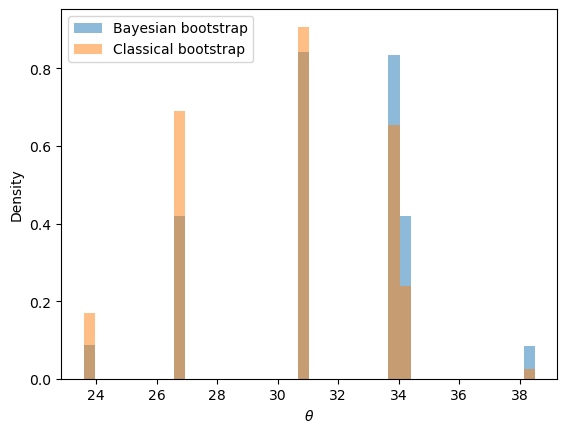

In [ ]:
plt.hist(theta_median_samples, bins=40, density=True, alpha=0.5, label="Bayesian bootstrap")
plt.hist(theta_median_bootstrap, bins=40, density=True, alpha=0.5, label="Classical bootstrap")
plt.legend()
plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.show()

For more on the Bayesian bootstrap and its connection to the classical bootstrap, I highly recommend the blog post https://www.sumsar.net/blog/2015/04/the-non-parametric-bootstrap-as-a-bayesian-model/ and the original paper on the Bayesian Bootstrap by Donald Rubin (1981). 